In [34]:
import requests
import pandas as pd 
import matplotlib.pyplot as plt

In [35]:
# Step 1: Get all networks
url = "https://api.citybik.es/v2/networks"
response = requests.get(url)
data = response.json()

# Step 2: Find the correct NYC network
network_id = None

for item in data['networks']:
    if item['id'] == 'citi-bike-nyc':  
        network_id = item['id']
        break

print("Using network:", network_id)

# Step 3: Fetch stations
url2 = f"https://api.citybik.es/v2/networks/{network_id}"
response2 = requests.get(url2)
data2 = response2.json()

stations = data2['network']['stations']

# Step 4: Create dataframe
df_bike = pd.DataFrame(stations)

print("Total bike stations:", df_bike.shape)
print(df_bike.head(10))

Using network: citi-bike-nyc
Total bike stations: (2306, 8)
                                 id                        name   latitude  \
0  0007398f39bd26118c9fdfd5197ccada        Chester Ave & 12 Ave  40.644367   
1  0096a3255aa8247f5a60322c9173d420             W 56 St & 8 Ave  40.765959   
2  009750d7dc4dec3f0fc06547e41ba3a8  S Portland Ave & Hanson Pl  40.685396   
3  00b598603e95ff6cd619487b42e1b87c             E 78 St & 2 Ave  40.772797   
4  00c998e78f71ad6b1a865fb2906d4326       87 St & Roosevelt Ave  40.748250   
5  00f0ea447a1af60aa053a510d944e623        E 157 St & River Ave  40.825737   
6  00f703e13e3bb5f7d5f2516656495d1f          E 17 St & Broadway  40.737006   
7  010f92292461543f36314829cb02afac  Central Ave & Flushing Ave  40.702831   
8  01505c113b8e95794b92a3f2228a15cb         Colonial Rd & 71 St  40.635370   
9  015f8c90cb9c0e8ebb1f11e4aeeaaa87        E 149 St & Eagle Ave  40.814046   

   longitude                          timestamp  free_bikes  empty_slots  \
0 -73

In [36]:
API_KEY = "9oeaHhv5e0jFlPTYM0ZkaLY6xIoUr9sX"
url = "https://transit.land/api/v2/rest/stops"
headers = {"apikey": API_KEY}
params = {
    "feed_onestop_id": "f-dr5r-nyctsubway",
    "limit": 400
}
response = requests.get(url, headers=headers, params=params)
data = response.json()
# print(data)
# Collect only the necessary data 
subway_list = []
for stop in data['stops']:
    subway_list.append({
        'name': stop['stop_name'],
        'lat': stop['geometry']['coordinates'][1],
        'lon': stop['geometry']['coordinates'][0]
    })
df_subway = pd.DataFrame(subway_list)
print("Total Subway Stations:",len(df_subway))
print(df_subway.head(10))


Total Subway Stations: 400
                        name        lat        lon
0  Van Cortlandt Park-242 St  40.889248 -73.898583
1                     238 St  40.884667 -73.900870
2                     231 St  40.878856 -73.904834
3         Marble Hill-225 St  40.874561 -73.909831
4                     215 St  40.869444 -73.915279
5                     207 St  40.864621 -73.918822
6                 Dyckman St  40.860531 -73.925536
7                     191 St  40.855225 -73.929412
8                     181 St  40.849505 -73.933596
9      168 St-Washington Hts  40.840556 -73.940133


In [37]:
#Question1 - Which Citi Bike stations are located nearest to MTA subway stations, and how accessible are they for commuters?

from geopy.distance import geodesic
results = []
# loop through each Citi Bike station
for i, citi_row in df_bike.iterrows(): #[AI-START] iterrows syntax shown by AI
    citi_location = (citi_row['latitude'], citi_row['longitude'])
    nearest_distance = float('inf')
    nearest_stop = ""
    #[AI-END]
    
    # loop through each subway stop to find the closest one
    for j, subway_row in df_subway.iterrows():
        subway_location = (subway_row['lat'], subway_row['lon'])
        distance = geodesic(citi_location, subway_location).kilometers
        
    # update if current distance is smaller than the best so far
        if distance < nearest_distance:
            nearest_distance = distance
            nearest_stop = subway_row['name']
            
    # store the result for this Citi Bike station
    results.append({
        'citi_station': citi_row['name'],
        'nearest_subway': nearest_stop,
        'distance_km': round(nearest_distance, 2)
    })
# convert results to dataframe
df_results = pd.DataFrame(results)

# Check dataset size
print(df_results.shape)

# Summary statistics for accessibility distances
print(df_results['distance_km'].describe())

# Show the Citi Bike stations closest to subway stations
df_results.sort_values("distance_km").head(10)

(2306, 3)
count    2306.000000
mean        0.734245
std         0.951773
min         0.000000
25%         0.240000
50%         0.400000
75%         0.760000
max         7.100000
Name: distance_km, dtype: float64


,citi_station,nearest_subway,distance_km
119,Jay St & York St,York St,0.00
2088,8 Ave & W 24 St,23 St,0.00
1377,10 Ave & W 215 St,215 St,0.01
1401,Wyckoff Ave & Gates Ave,Myrtle-Wyckoff Avs,0.01
2249,Beverley Rd & Nostrand Ave,Beverly Rd,0.01
1668,Fulton St & Waverly Ave,Clinton-Washington Avs,0.01
830,8 Ave & W 16 St,14 St,0.01
1302,Union Ave & Wallabout St,Flushing Av,0.01
1070,E 51 St & Lexington Ave,51 St,0.01
1854,Broadway & 74 St,Jackson Hts-Roosevelt Av,0.02


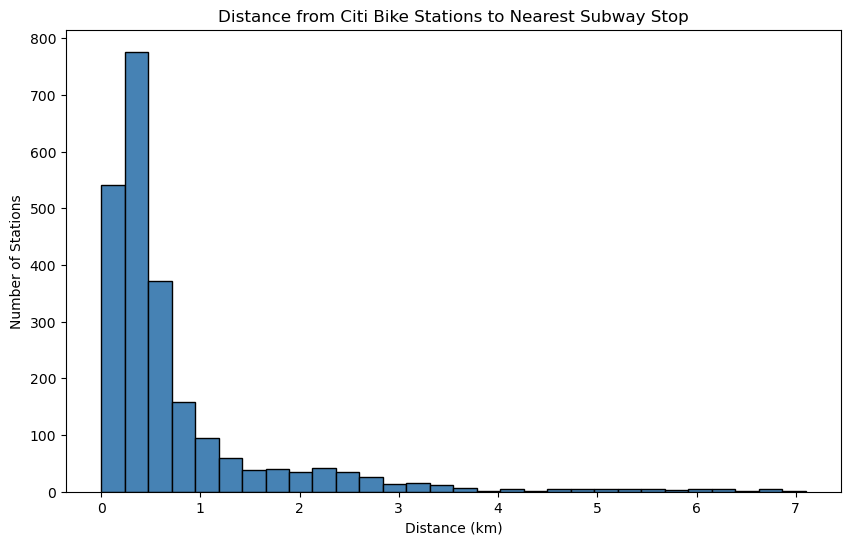

In [38]:
plt.figure(figsize=(10, 6))
plt.hist(df_results['distance_km'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distance from Citi Bike Stations to Nearest Subway Stop')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Stations')
# plt.axvline(df_results['distance_km'].mean(),color='red',linestyle='--',label=f'Mean: {df_results["distance_km"].mean():.2f} km')
# plt.legend()
plt.show()

In [39]:
# Question 2: Which NYC neighborhoods are most dependent on Citi Bike as a transit alternative when public transportation is unavailable or delayed?

# Calculate total station capacity 
df_bike["total_capacity"] = df_bike["free_bikes"] + df_bike["empty_slots"]

# Calculate percentage of bikes currently available at each station
df_bike["pct_available"] = (
    df_bike["free_bikes"] / df_bike["total_capacity"]
) * 100

# Merge Citi Bike data with subway distance dataset using station name
df_combined = df_bike.merge(
    df_results,
    left_on="name",
    right_on="citi_station",
    how="left"
)

# Function to classify each station into a broad NYC area based on coordinates
def assign_area(row):
    lat = row["latitude"]
    lon = row["longitude"]

    if lat > 40.80:
        return "Bronx / Upper Manhattan"
    elif lon < -73.95:
        return "Manhattan"
    elif lon < -73.85:
        return "Brooklyn"
    else:
        return "Queens"
        
# Apply area classification to each station
df_combined["area"] = df_combined.apply(assign_area, axis=1)

# Preview key columns to verify calculations and grouping
print(df_combined[["name", "area", "distance_km", "free_bikes", "pct_available"]].head())

# Check dataset size after merging and processing
print(df_combined.shape)

                         name       area  distance_km  free_bikes  \
0        Chester Ave & 12 Ave  Manhattan         0.39          20   
1             W 56 St & 8 Ave  Manhattan         0.27          36   
2  S Portland Ave & Hanson Pl  Manhattan         0.09          16   
3             E 78 St & 2 Ave  Manhattan         0.36           0   
4       87 St & Roosevelt Ave   Brooklyn         0.23           4   

   pct_available  
0      95.238095  
1      73.469388  
2      72.727273  
3       0.000000  
4      17.391304  
(2308, 14)


In [40]:
# Threshold for defining high Citi Bike dependency (stations >1 km from subway)
# Before this, I had hardcoded this as DEPENDENCY_THRESHOLD = 1.0. Changed name based on AI suggestion.
distance_limit = 1.0

# flag stations with high Citi Bike dependency
df_combined["high_citibike_dependency"] = (
    df_combined["distance_km"] > distance_limit
)

# summarize by area
question2_summary = (
    df_combined
    .groupby("area")
    .agg(
        total_citi_stations=("name", "count"),
        high_dependency_stations=("high_citibike_dependency", "sum"),
        average_distance_to_subway_km=("distance_km", "mean"),
        average_bikes_available=("free_bikes", "mean"),
        average_capacity=("total_capacity", "mean")
    )
    .reset_index()
)
# calculate percentage of high dependency stations per area
question2_summary["dependency_percent"] = (
    question2_summary["high_dependency_stations"] /
    question2_summary["total_citi_stations"] * 100
)

# sort by highest dependency first
question2_summary = question2_summary.sort_values(
    ["dependency_percent", "average_distance_to_subway_km"],
    ascending=False
)

question2_summary

,area,total_citi_stations,high_dependency_stations,average_distance_to_subway_km,average_bikes_available,average_capacity,dependency_percent
3,Queens,3,1,0.616667,27.000000,27.666667,33.333333
1,Brooklyn,738,182,0.742439,11.157182,22.161247,24.661247
2,Manhattan,1055,228,0.899384,20.579147,36.899526,21.611374
0,Bronx / Upper Manhattan,512,18,0.381289,8.710938,21.376953,3.515625


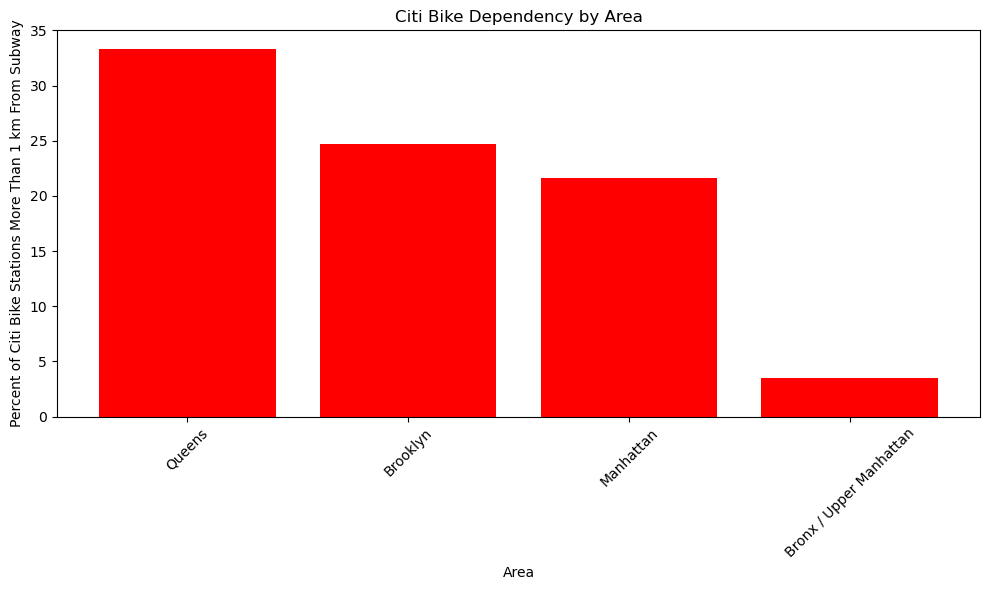

In [41]:
plt.figure(figsize=(10, 6))

plt.bar(
    question2_summary["area"],
    question2_summary["dependency_percent"],
    color = "red"
)

plt.title("Citi Bike Dependency by Area")
plt.xlabel("Area")
plt.ylabel("Percent of Citi Bike Stations More Than 1 km From Subway")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
# Question3: How many Citi Bike stations near subway stops suffer from low bike availability?

# calculate total capacity and availability percentage
df_bike['total_capacity'] = df_bike['empty_slots'] + df_bike['free_bikes']
df_bike['pct_available'] = df_bike['free_bikes'] / df_bike['total_capacity'] * 100

# AI suggested using merge instead of concat
# merge bike and subway distance data on station name
df_combined = df_bike.merge(df_results, left_on='name', right_on='citi_station')

# filter: stations near subway (< 1.5km) with low availability (< 20%)
df_filtered = df_combined[
    (df_combined['distance_km'] < 1.5) &
    (df_combined['pct_available'] > 20)
]
# sort by lowest availability first
df_filtered = df_filtered.sort_values('pct_available', ascending=True)

# display outputs
print(df_filtered[['name', 'distance_km', 'pct_available', 'free_bikes']].head(10))
print("Number of stations:", len(df_filtered))

                                       name  distance_km  pct_available  \
872                 Bank St & Washington St         0.57      20.689655   
1048         Lafayette Ave & Stuyvesant Ave         0.35      20.833333   
992          Fort Washington Ave & W 173 St         0.25      20.833333   
1942  Van Cortlandt Park S & Gouverneur Ave         0.78      20.833333   
1356                 College Ave & E 169 St         0.48      21.052632   
1194                  E 133 St & Cypress Pl         0.42      21.052632   
2046                 Pacific St & Ralph Ave         0.32      21.052632   
2110         Fort Washington Ave & W 190 St         0.27      21.052632   
394               Jerome Ave & Anderson Ave         0.35      21.052632   
1791                        107 St & 32 Ave         1.08      21.052632   

      free_bikes  
872            6  
1048           5  
992            5  
1942           5  
1356           4  
1194           4  
2046           4  
2110           4  
394

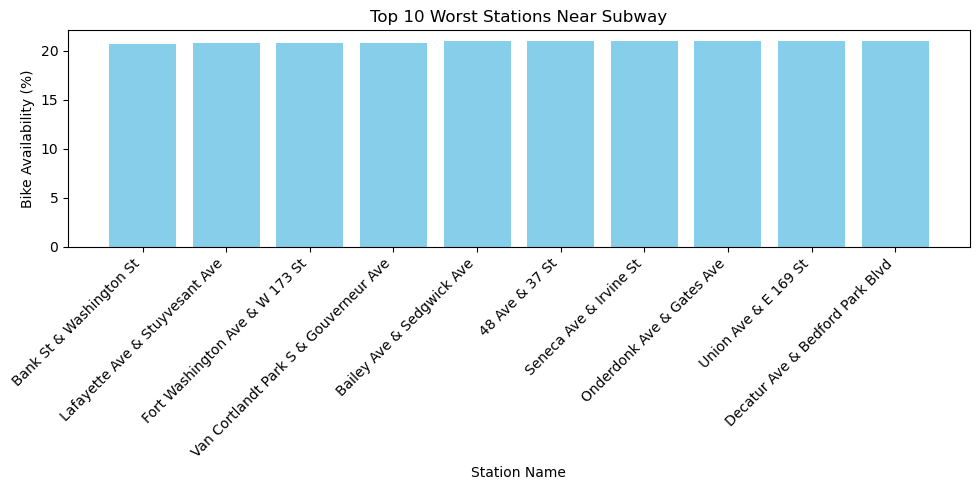

In [43]:
df_plot = df_filtered.sort_values('pct_available').head(10)
plt.figure(figsize=(10,5))
plt.bar(df_plot['name'], df_plot['pct_available'], color='skyblue')
plt.xlabel('Station Name')
plt.ylabel('Bike Availability (%)')
plt.title('Top 10 Worst Stations Near Subway')
# AI suggested rotating x-axis labels for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
# Developed with AI assistance for conceptual guidance
# Code written independently based on guided discussion
# walking limit (0.4 km ~ 5 min walk)
walkdistance_limit = 0.4

# filter far subway stops
far_stops = df_results[df_results["distance_km"] > walkdistance_limit]

print("Number of underserved subway stops:", len(far_stops))

# total stops
print("Total subway stops:", len(df_results))

# percent underserved
percent = len(far_stops) / len(df_results) * 100
print("Percentage underserved:", round(percent, 1), "%")

# top 10 worst stops
top10 = far_stops.sort_values("distance_km", ascending=False)
print(top10[["citi_station", "distance_km"]].head(10))

Number of underserved subway stops: 1144
Total subway stops: 2306
Percentage underserved: 49.6 %
                      citi_station  distance_km
1276    Danforth Ave & Sullivan Dr         7.10
2029       Danforth Ave & JFK Blvd         6.83
1002  West Side Ave & Stegman Pkwy         6.76
849           Ferris Triangle Park         6.63
523    Woodlawn Ave & Sterling Ave         6.63
1410              Wade St & MLK Dr         6.39
489             Ocean Ave & New St         6.36
1980           Danforth Light Rail         6.35
1437      West Side Ave Light Rail         6.35
474    Mallory Ave & Roosevelt Ave         6.31


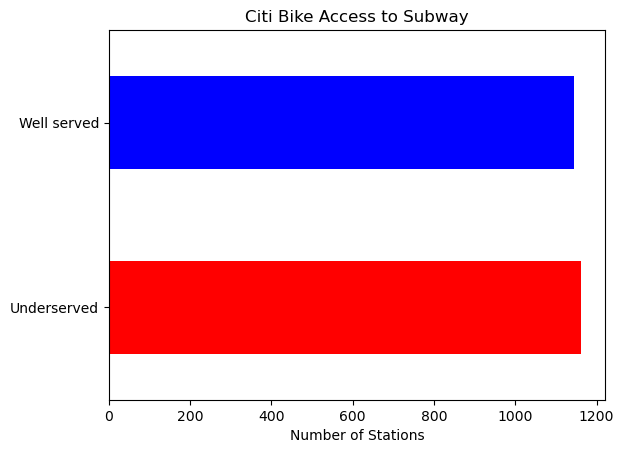

In [45]:
#I asked the AI for a chart suggestion because I want to present the data very well.
# But all the code is written by me. 
df_results['served'] = df_results['distance_km'] <= 0.4
counts = df_results['served'].value_counts()
counts.index = ['Underserved', 'Well served']
colors = ['red', 'blue']
counts.plot(kind='barh',color=colors)
plt.title("Citi Bike Access to Subway")
plt.xlabel("Number of Stations")
plt.show()

In [46]:
# Question 5 - Which neighborhoods in NYC are underserved by both the public transit system and Citi Bike combined?

# Got an error here because "area" was not being created correctly due to function/execution order issues.
# Used AI suggestion to ensure assign_area() is defined before applying it.
#[AI-Start] 
df_combined["area"] = df_combined.apply(assign_area, axis=1)
#[AI-End]

# define underserved stations: far from subway AND low bike availability
df_combined["bike_side_underserved"] = (
    (df_combined["distance_km"] > 1.0) &
    (df_combined["pct_available"] < 20)
)

# Group stations by area and calculate summary statistics (total stations, underserved stations, and averages)
# Then compute percentage of underserved stations and sort areas from highest to lowest
question5_summary = (
    df_combined
    .groupby("area")
    .agg(
        total_citi_stations=("name", "count"),
        bike_side_underserved_stations=("bike_side_underserved", "sum"),
        avg_distance_to_subway=("distance_km", "mean"),
        avg_bike_availability_pct=("pct_available", "mean")
    )
    .reset_index()
)

question5_summary["underserved_percent"] = (
    question5_summary["bike_side_underserved_stations"] /
    question5_summary["total_citi_stations"] * 100
)

question5_summary = question5_summary.sort_values(
    "underserved_percent",
    ascending=False
)

question5_summary

,area,total_citi_stations,bike_side_underserved_stations,avg_distance_to_subway,avg_bike_availability_pct,underserved_percent
2,Manhattan,1055,58,0.899384,53.407437,5.497630
1,Brooklyn,738,28,0.742439,49.603821,3.794038
0,Bronx / Upper Manhattan,512,5,0.381289,40.465313,0.976562
3,Queens,3,0,0.616667,96.969697,0.000000


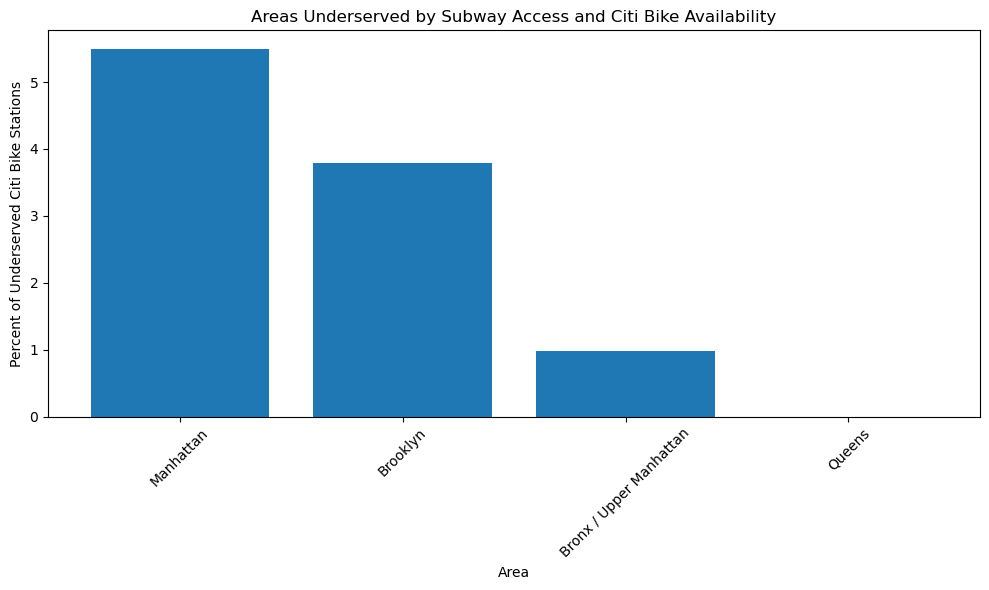

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    question5_summary["area"],
    question5_summary["underserved_percent"]
)

plt.title("Areas Underserved by Subway Access and Citi Bike Availability")
plt.xlabel("Area")
plt.ylabel("Percent of Underserved Citi Bike Stations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()